# Вариант №21
Найти точку минимума функции
$$
f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75, \\
[x_1 = 0, x_2 = −3].
$$
методом Ньютона.
В окрестности точки минимума построить линии уровня и траекторию поиска (на одном графике). За своевременное выполнение задания начисляется 6 баллов.

Реализовав дополнительно следующие методы можно получить по 3 балла за каждый метод: 
- метод случайного поиска +
- метод Нелдера-Мида 
- метод Пауэлла +
- метод Хука-Дживса
- метод Розенброка +

Для того, чтобы лабораторная работа была засчитана требуется оформление отчета (с формулами) с описанием используемых методов в формате Jupyter+Markdown+LaTeX.

In [134]:
import matplotlib.pyplot as plt
import numpy as np

In [135]:
Y_MIN_BOUND = -50
Y_MAX_BOUND =  50
X_MIN_BOUND = -50
X_MAX_BOUND =  50

In [136]:
# def f(x1, x2):
#     return x1**2 + 4 * x1 + 3 * x2**2 - 39 * x2 + 129.75
def f(xy):
    return 2*xy[0]**2 + 4 * xy[0] + 3 * xy[1]**2 - 39 * xy[1] + 129.75

In [137]:
x = np.linspace(-50, 50, 1000)
y = x
x, y = np.meshgrid(x,y)
z = 2*x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75

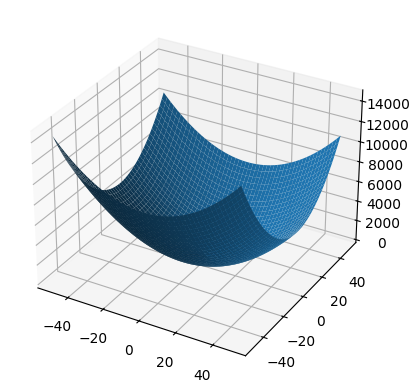

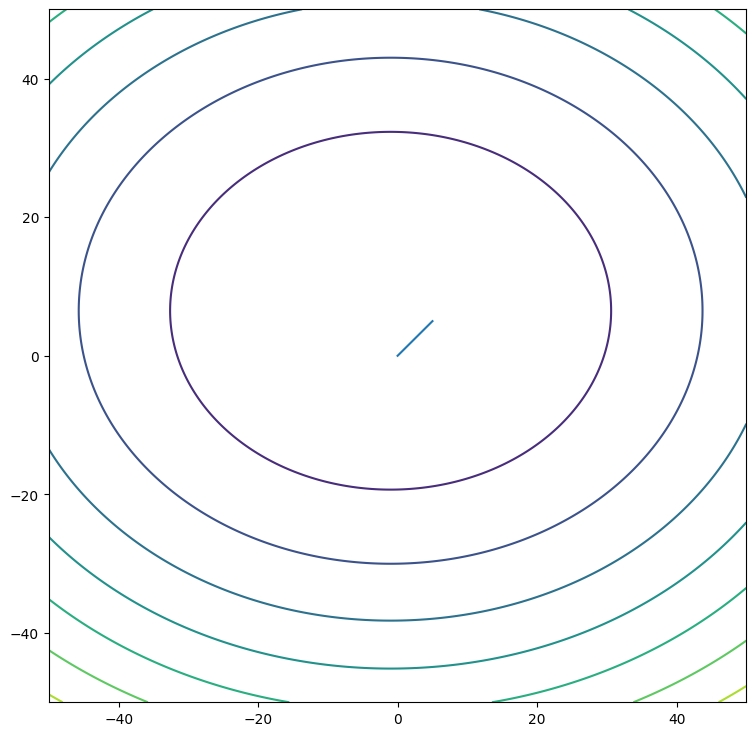

In [138]:
fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')
figu.plot_surface(x, y, z, label='sin')
# f.set(zlim=(0, 10))
# figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0,5], [0, 5])



# Метод случайного поиска
Идея: Генерируем $N$ точек в области определения функции и находим значение функции в этих точках, находим точку в которой функция принемает минимальное значение(назовём её "лучшая"), будем считать её минимумом функции.

In [139]:
def randomSearch(N):
    best = (X_MIN_BOUND, Y_MIN_BOUND)
    best_val = f(best)
    dots = []
    for _ in range(N):
        x = np.random.uniform(X_MIN_BOUND, X_MAX_BOUND)
        y = np.random.uniform(Y_MIN_BOUND, Y_MAX_BOUND)
        val = f((x, y))
        if val < best_val:
            best_val = val
            best = (x, y)
        dots.append((x, y))
    return best, dots

Результат работы Метода случайного поиска:
Полученная точка: 
x = -5.2120800928458735
y = 4.904930953672483
f_min = 44.115973204753516


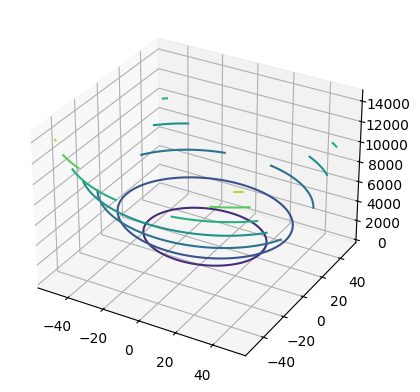

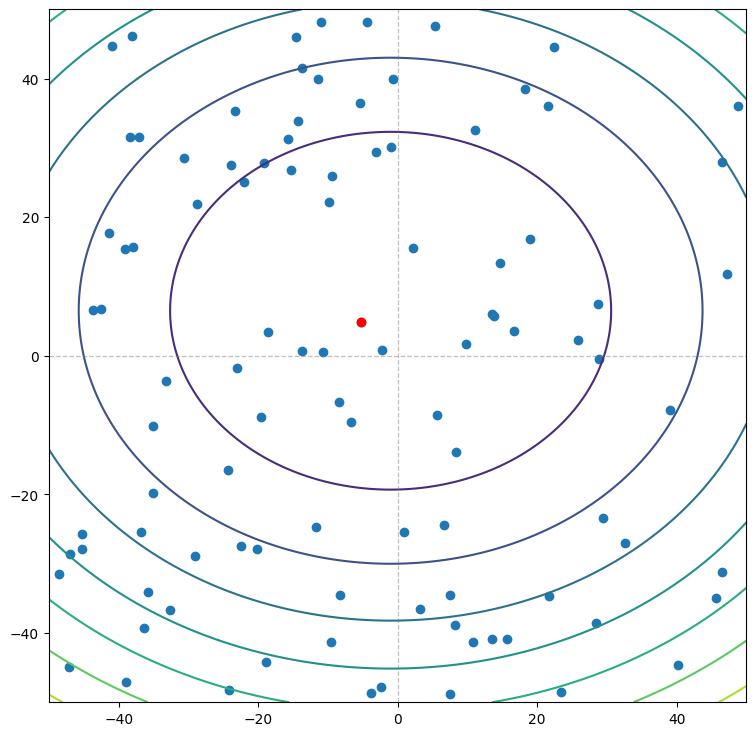

In [140]:
N = 100
res, dots = randomSearch(N)

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

# f.set(zlim=(0, 10))
figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

X_dots = [dot[0] for dot in dots]
Y_dots = [dot[1] for dot in dots]
plt.scatter(X_dots, Y_dots)
plt.scatter(res[0], res[1], color='red')


print('Результат работы Метода случайного поиска:')
print(f'Полученная точка: \nx = {res[0]}\ny = {res[1]}\nf_min = {f(res)}')

# Метод Ньютона

$$
f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75, \\
[x^0_1 = 0, x^0_2 = −3].
$$

Метод Ньютона для поиска экстремума функции:
$$ \vec{x}^{k+1} = \vec{x}^k + p^k $$

$$ p^k = -[\nabla^2 f(x^k)]^{-1} \nabla f(x^k) $$
Перейдём к системе линейных уравнений относительно $p^k$
$$ [\nabla^2 f(x^k)] p^k = -\nabla f(x^k) $$

Матрица Гессе - матрица, состоящая из вторых производных функции
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2 } \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2}
\end{pmatrix}
$$
Аналитически найдём часные производные функции $f$:

$ \frac{\partial f}{\partial x_1} = 4x_1 + 4 $

$ \frac{\partial f}{\partial x_2} = 6x_2 - 39 $

$\frac{\partial^2 f}{\partial x_1^2} = 4 $ 

$\frac{\partial^2 f}{\partial x_1 \partial x_2} = 0 $

$\frac{\partial^2 f}{\partial x_2^2} = 6 $

$\frac{\partial^2 f}{\partial x_2 \partial x_1} = 0 $

Запишем матрицу Гессе и набла для нашей функции:
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
4 & 0 \\
0 & 6
\end{pmatrix} \\
\nabla f(x^k) = 
\begin{pmatrix}
4x_1 + 4 \\
6x_2 - 39
\end{pmatrix}
$$

In [141]:
def nabl(x):
    res = np.zeros((2, 1))
    res[0] = 4 * x[0] + 4
    res[1] = 6 * x[1] - 39
    return res

[-2, 6.5] [-2, 6.5] [[-0.25       -0.        ]
 [-0.         -0.16666667]]
Найденный минимум:
x = -1.0
y = 6.5
f_min = 1.0


([[array([-1.]), array([6.5])], [array([-1.]), array([6.5])]],
 [array([-1.]), array([6.5])])

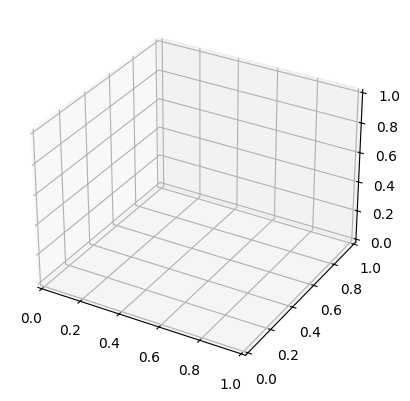

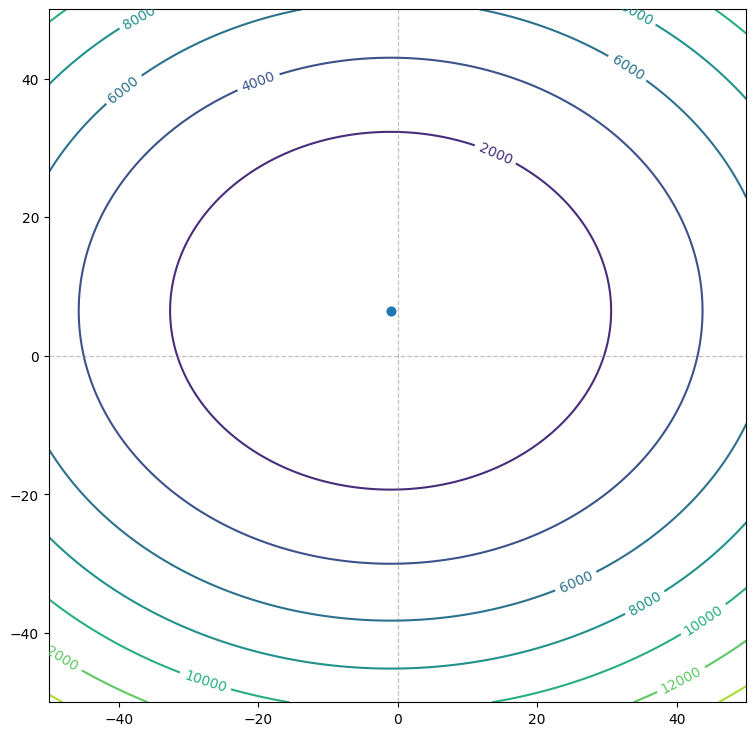

In [142]:
x_0 = [-2, 6.5]
Eps = 0.0001

x_current = x_0
x_next = x_0

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

# plt.xlim(-10, 10)
# plt.ylim(-10, 10)
Gesse = [
    [4, 0],
    [0, 6]
]
coef = - np.linalg.inv(Gesse)
print(x_current, x_next, coef)

dots = []

while np.linalg.norm(nabl(x_current)) > Eps:

    x_current = x_next.copy()

    p_k = np.dot(coef, nabl(x_current))

    x_next = [x_current[i] + p_k[i] for i in range(2)]

    dots.append(x_next)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]
plt.scatter(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

result_dot = dots[-1]

print(f'Найденный минимум:\nx = {result_dot[0][0]}\ny = {result_dot[1][0]}\nf_min = {f(result_dot)[0]}')
dots, result_dot

In [143]:
f((-2, 6.5))

3.0

# Метод Розенброка

Идея метода заключается в том, что выбирается система ортогональных направлений $p^k_1 , p^k_2, ..., p^k_n$, в каждом из которых последовательно ищется минимальное значение, после чего система направлений поворачивается так, чтобы одна из осей совпала с направлением полного перемещения, а остальные были ортогональны между собой. Алгоритм Розенброка состоит из двух этапов:
## Покоординатный спуск. 

Пусть $x^k$ - вектор $k$-приближения и $p^k_1 , p^k_2, ..., p^k_n$ - система ортогональных направлений. На первой итерации это может быть ортонормированная система координат. Начиная с заданного $x^k$ последовательно осуществляем минимизацию функции $f(x)$ в направлениях, соответстствующих $p^k_1 , p^k_2, ..., p^k_n$, находя последовательные приближения:
$$
x^{k+1}_1 = x^k_1 + \lambda^k_1p^k_1, \qquad \lambda^k_1 = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_1) \\
\cdots \\
x^{k+1}_n = x^k_n + \lambda^k_n p^k_n, \qquad \lambda^k_n = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_n)
$$

In [ ]:
def scalarMult(a, b):
    res = 0
    for i in range(len(a)):
        res += a[i] * b[i]
    return res

def proj(b, a):
    coef = scalarMult(a, b) / scalarMult(b, b)

    return  [coef * el for el in a]

In [192]:
# Реализация Алгоритма Грама-Шмидта (см. SLAU.ipynb)
def algGramSchmidt(a):
    vectors = [np.array(v, dtype=float) for v in a]
    orthogonal = []
    
    for i in range(len(vectors)):
        u = vectors[i].copy()
        
        for w in orthogonal:
            # Проекция v на w
            proj = np.dot(vectors[i], w) / np.dot(w, w) * w
            u = u - proj
        
        if np.linalg.norm(u) > 1e-10:
            u = u / np.linalg.norm(u)
            orthogonal.append(u)
        else:
            orthogonal.append(vectors[i].copy())

    return orthogonal

In [193]:
# Нахождение минимума относительно точки x в направлении p с помощью метода золотого сечения
def line_search(x, p, tol=1e-6):
    phi = (1 + np.sqrt(5)) / 2
    a, b = -50, 50  # начальный интервал
    
    while b - a > tol:
        c = b - (b - a) / phi
        d = a + (b - a) / phi
        if f(x + c*p) < f(x + d*p):
            b = d
        else:
            a = c
    return (a + b) / 2

[[1. 0.]
 [0. 1.]]
[[1. 0.]
 [0. 1.]]
a [[2643.2500064  2643.2500064 ]
 [1122.24999448 1122.24999448]] p =  [array([0.70710678, 0.70710678]), array([1122.24999448, 1122.24999448])]
[array([0.70710678, 0.70710678]), array([1122.24999448, 1122.24999448])]
[array([0.70710678, 0.70710678]), array([1122.24999448, 1122.24999448])]
a [[1.35018618e-32 1.35018618e-32]
 [6.75093091e-33 6.75093091e-33]] p =  [array([1.35018618e-32, 1.35018618e-32]), array([6.75093091e-33, 6.75093091e-33])]
Сошелся на итерации 2
Найденный минимум: x1 = -0.9999998470808791, x2 = 6.500000082441481
Значение функции: 1.0000000000000568
Число итераций: 2


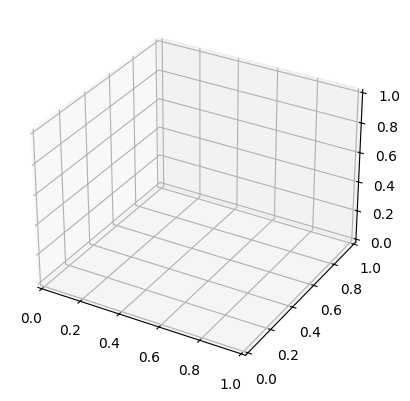

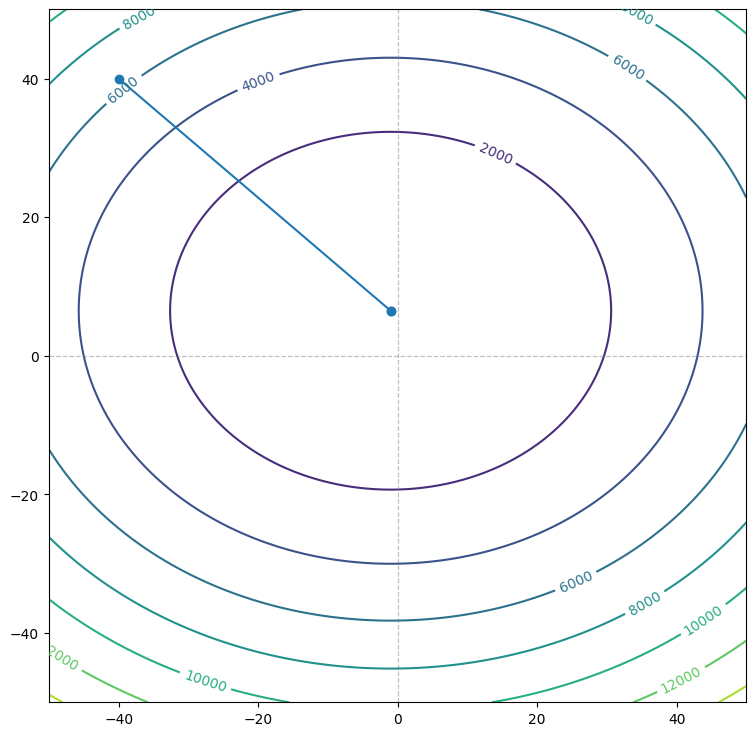

In [198]:
def Rozenbrock(x0, iters=10, eps=1e-6):
    x = np.array(x0, dtype=float)
    
    dots = [x0]
    p = np.eye(2)

    for iteration in range(iters):
        x_start = x.copy()
        lambdas = np.zeros(2)
        
        # Этап 1: покоординатный спуск вдоль направлений p
        for i in range(2):
            print(p)
            lam = line_search(x, p[i])
            lambdas[i] = lam
            x = x + lam * p[i]
        
        # Этап 2: построение новых направлений (поворот)
        
        # Сортируем lambdas по убыванию абсолютных значений
        idx = np.argsort(-np.abs(lambdas))

        p = [lambdas[ind] for ind in idx]
        
        # Строим векторы A_i
        A = []
        for i in range(2):
            vec = np.zeros(2)
            for j in range(i, 2):
                vec += lambdas[j] * p[j]
            A.append(vec)
        A = np.array(A)
        
        
        # Обновляем направления
        p = algGramSchmidt(A)
        print("a", A, "p = ", p)
        
        dots.append(x)

        # Проверка сходимости
        if np.linalg.norm(x - x_start) < eps:
            print(f"Сошелся на итерации {iteration+1}")
            break
        
    return x, f(x), iteration+1, dots

# Запуск
x0 = np.array([-40, 40])  # далеко от минимума
x_min, f_min, iters, dots = Rozenbrock(x0)

print(f"Найденный минимум: x1 = {x_min[0]}, x2 = {x_min[1]}")
print(f"Значение функции: {f_min}")
print(f"Число итераций: {iters}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

# Метод Пауэлла

Последовательно выполнять одномерную минимизацию вдоль системы линейно независимых направлений, постепенно заменяя их на сопряжённые, что обеспечивает квадратичную сходимость.

In [130]:
def sumMult(x, y, b):
    return [x[i] + b * y[i] for i in range(2)] # x + b*y

[[-40, 40]]
[[-40, 40], array([-0.99999985,  6.50000008])]
Минимум в точке: [-0.99999985  6.50000008]
Значение функции: 1.0000000000000568
Итераций: 1


[[-40, 40],
 array([-0.99999985,  6.50000008]),
 array([-0.99999985,  6.50000008])]

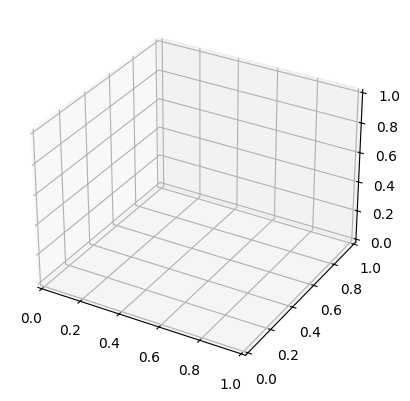

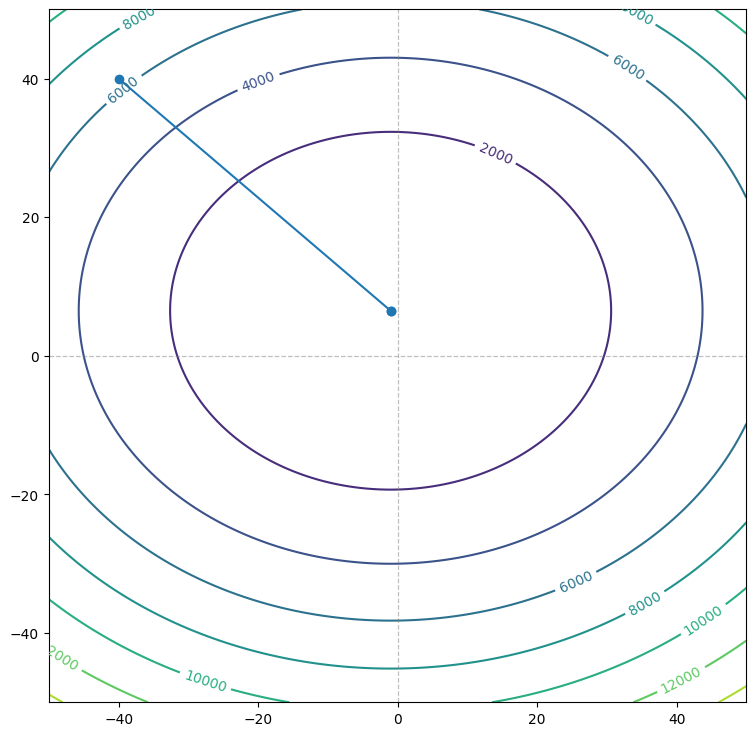

In [ ]:
def powell(x0, iters=10, eps=1e-6):
    x = np.array(x0, dtype=float)
    
    dots = [x0]
    p = np.eye(2)  # начальные направления
    
    for iteration in range(iters):
        print(dots)
        x_start = x.copy()
        
        # Шаг 1: поиск вдоль всех направлений
        for i in range(2):
            lam = line_search(x, p[i])
            x = x + lam * p[i]
        
        x_end = x.copy()
        d_new = x_end - x_start
        
        # Шаг 2: проверка замены направлений
        x_test = 2*x_end - x_start
        if f(x_test) >= f(x_start):
            # не меняем направления
            pass
        else:
            # меняем направления
            
            p[0] = p[1]
            p[1] = d_new
            lam = line_search(x_end, p[1])
            x = x_end + lam * p[1]
        dots.append(x)
        # Шаг 3: проверка сходимости
        if np.linalg.norm(x - x_start) < eps:
            break
        
    return x, f(x), iteration, dots


x0 = [-40, 40]


x_min, f_min, it, dots = powell(x0)
print(f"Минимум в точке: {x_min}")
print(f"Значение функции: {f_min}")
print(f"Итераций: {it}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

dots

# Прим

Результатом стало нахождение минимума за одну итерацию. Это происходит из-за того что наша функция гладкая и градиент в любой точке направлен на точку локального минимума 